In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("online_retail.csv")

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
df.shape

(541909, 8)

In [5]:
cols = df.columns
print(cols)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')


In [6]:
df.drop(["CustomerID"], axis=1, inplace=True)
df.shape

(541909, 7)

In [7]:
df.dropna()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,France


In [9]:
cols = df.columns

In [12]:
for i in cols:
    print(f"{i} contains: {df[i].nunique()}")

InvoiceNo contains: 25900
StockCode contains: 4070
Description contains: 4223
Quantity contains: 722
InvoiceDate contains: 23260
UnitPrice contains: 1630
Country contains: 38


In [17]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# **Q1) Which products generate the most revenue?**

In [15]:
revenue_by_product = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Top Revenue Products:")
print(revenue_by_product.head(10))

Top Revenue Products:
Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: Revenue, dtype: float64


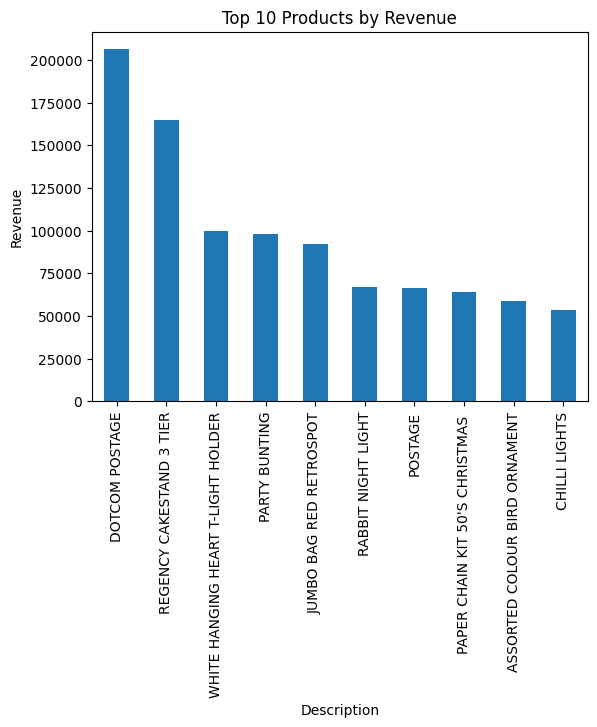

In [20]:
revenue_by_product.head(10).plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.show()

# **Q2) How do sales change over time?**

In [23]:
monthly_sales = (
    df.groupby(pd.Grouper(key="InvoiceDate", freq="ME"))["Revenue"]
    .sum()
)

print(monthly_sales.tail())

InvoiceDate
2011-08-31     682680.510
2011-09-30    1019687.622
2011-10-31    1070704.670
2011-11-30    1461756.250
2011-12-31     433668.010
Freq: ME, Name: Revenue, dtype: float64


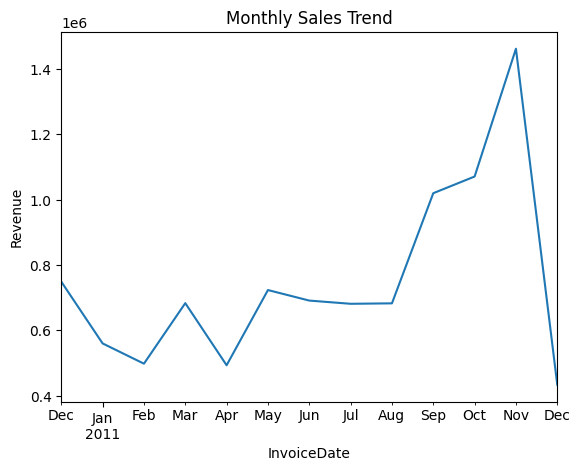

In [24]:
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()

# **Q3) Which categories or regions are most profitable?**

In [25]:
revenue_by_country = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Most Profitable Countries:")
print(revenue_by_country.head(10))

Most Profitable Countries:
Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64


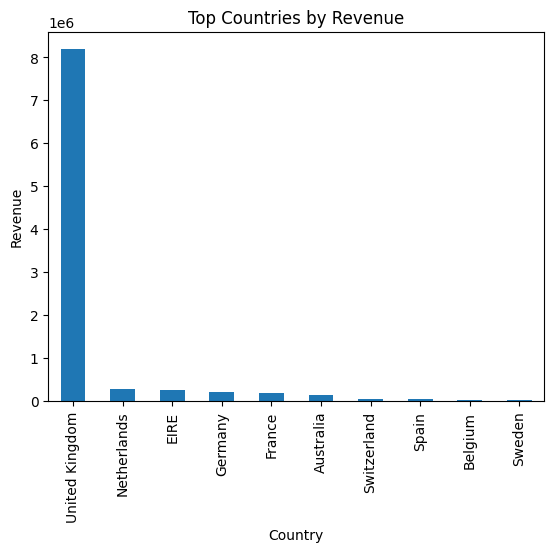

In [26]:
revenue_by_country.head(10).plot(kind="bar")
plt.title("Top Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

# **Q4) Where should the business focus to grow faster?**

In [28]:
country_time = df.groupby(
    [pd.Grouper(key="InvoiceDate", freq="ME"), "Country"]
)["Revenue"].sum().unstack()

growth_rate = country_time.pct_change()

# Average growth
avg_growth = growth_rate.mean().sort_values(ascending=False)

print("Fastest Growing Countries:")
print(avg_growth.head(10))

Fastest Growing Countries:
Country
Hong Kong                    inf
Netherlands           127.588141
Denmark                 8.626732
Australia               4.767184
Finland                 3.474185
Cyprus                  3.179476
Italy                   2.277054
Unspecified             1.458280
Sweden                  1.294073
European Community      0.597922
dtype: float64


In [29]:
summary = pd.DataFrame({
    "Revenue": revenue_by_country,
    "Growth": avg_growth
}).dropna()

print("Best Markets for Expansion:")
print(summary.sort_values(by=["Revenue", "Growth"], ascending=False).head(10))

Best Markets for Expansion:
                    Revenue      Growth
Country                                
United Kingdom  8187806.364    0.031356
Netherlands      284661.540  127.588141
EIRE             263276.820    0.390901
Germany          221698.210    0.080786
France           197403.900    0.303310
Australia        137077.270    4.767184
Switzerland       56385.350    0.378422
Spain             54774.580    0.405958
Belgium           40910.960    0.122653
Sweden            36595.910    1.294073
